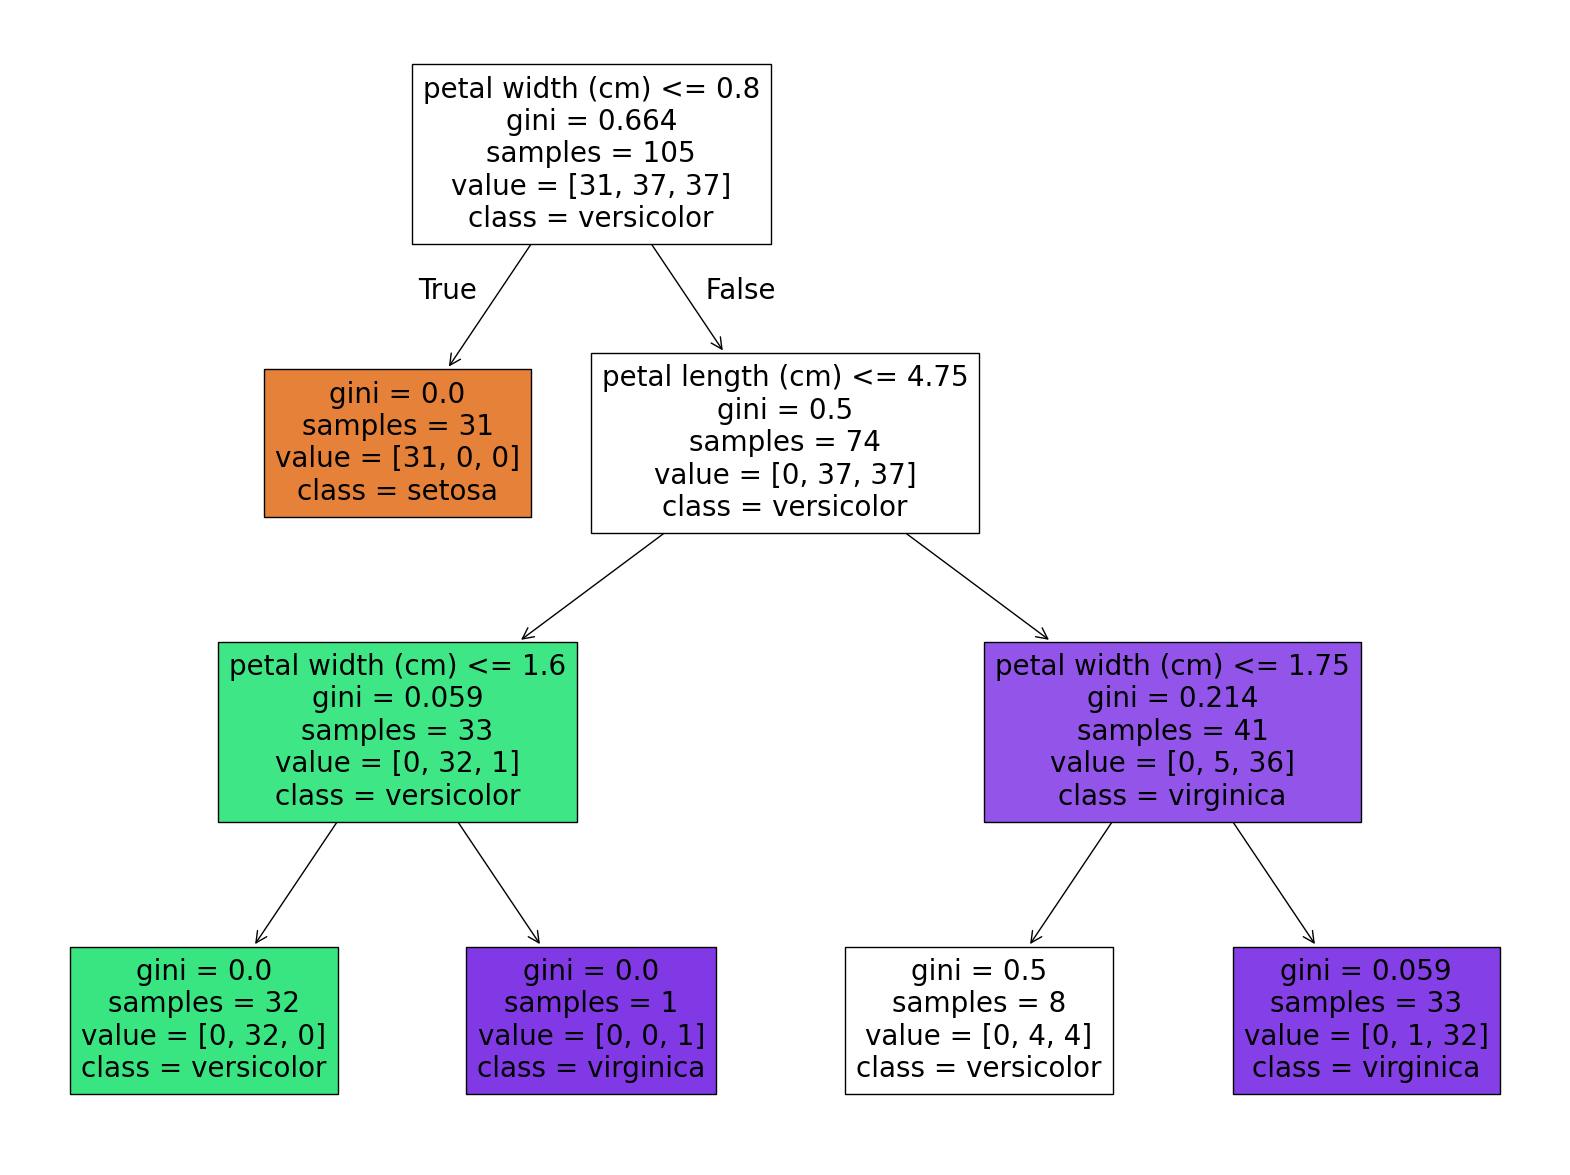

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

1.0


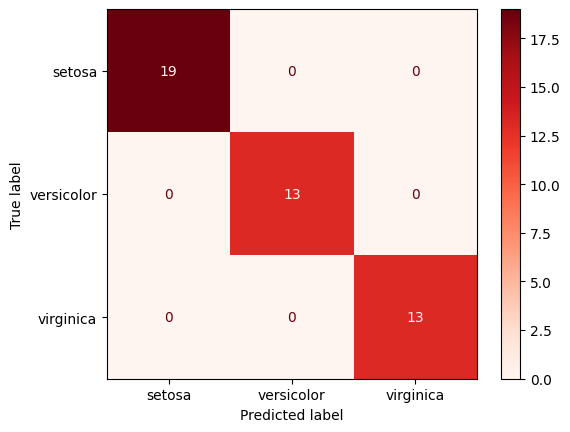

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

iris=load_iris()
x=iris.data
y=iris.target

df=pd.DataFrame(np.c_[iris["data"], iris["target"]],
                columns=iris["feature_names"]+ ["target"])

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.3, random_state=42)

model=DecisionTreeClassifier(criterion="gini", max_depth=3)
model.fit(x_train, y_train)

plt.figure(figsize=(20, 15))
plot_tree(model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

y_predict=model.predict(x_test)

report=classification_report(y_test, y_predict)
print(report)

accuracy=accuracy_score(y_test, y_predict)
print(accuracy)

cm=confusion_matrix(y_test, y_predict)
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Reds)
plt.show()

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

try:
  import seaborn as sns
  df=sns.load_dataset("titanic")

except ImportError:
  titanic_url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
  df = pd.read_csv(titanic_url)

print(df.head())

print(df.isnull().sum())

df=df.drop(columns=["deck"])

df["age"].fillna(df["age"].median(), inplace=True)
df["embarked"].fillna(df["embarked"].mode([0]), inplace=True)
df["embark_town"].fillna(df["embark_town"].mode([0]), inplace=True)

print(df.head())

col_to_convert=df.select_dtypes(include=["bool", "category", "object"]).columns

if "survived" in col_to_convert:
  col_to_convert=col_to_convert.drop("survived")

df=pd.get_dummies(df, columns=col_to_convert, drop_first=True)

x=df.drop(columns=["survived"])
y=df["survived"]

x,y=x.align(y,join="inner",  axis=0)

print(df.head())
print(df.isnull().sum())

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=43)

print(x_train.shape)
print(x_test.shape)

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck      

/tmp/ipykernel_7328/4113155080.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)
/tmp/ipykernel_7328/4113155080.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 